# Week 2 · Notebook 2 — Cooling Schedules, Convergence Theory and Alternative Acceptance Rules

**Goals**
- View SA as an **inhomogeneous Markov chain** and state the convergence theory precisely: the logarithmic schedule
  of Geman & Geman (1984) and **Hajek's theorem** (1988): $T_k = c/\log(k+1)$ converges in probability to the global
  optima iff $c \ge d^{\ast}$, the depth of the deepest non-global local minimum.
- **Demonstrate Hajek's threshold exactly** (no sampling noise) by propagating the full distribution of SA on a
  constructed landscape whose $d^{\ast}$ is computed independently.
- Implement the practical schedules — geometric, linear, logarithmic, adaptive acceptance-rate targeting
  (Lam & Delosme), reheating — and principled initial-temperature selection from a target acceptance ratio.
- Implement the deterministic/alternative acceptance rules: threshold accepting (Dueck & Scheuer 1990), great deluge
  and record-to-record travel (Dueck 1993), late acceptance hill climbing (Burke & Bykov) — and compare everything at
  an **equal evaluation budget** on Sherrington–Kirkpatrick spin glasses, with paired multi-seed statistics.

**Prerequisites:** Notebook 1 (Metropolis rule, detailed balance, Boltzmann concentration, spectral gap).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
from itertools import product
from scipy.optimize import brentq
from scipy.stats import wilcoxon
from utils import PALETTE

## 1. SA as an inhomogeneous Markov chain

With a schedule $(T_k)$, SA is the Markov chain with time-dependent kernels $P_k = P_{T_k}$ (Metropolis kernel at
temperature $T_k$); the law of $X_k$ is $\mu_k = \mu_0 P_1 P_2 \cdots P_k$. Two classical viewpoints:

* **Homogeneous (quasi-equilibrium) view** — hold $T$ fixed for a *Markov chain of length* $L$ long enough to
  (nearly) reach $\pi_T$, then lower $T$ (Kirkpatrick et al. 1983; Aarts & van Laarhoven 1985). Each stage is a
  chain of Notebook 1; its length must exceed the relaxation time $\approx e^{m/T}$, which explodes as $T\to0$.
* **Inhomogeneous view** — let $T_k$ change every step and ask when $\mu_k(S^{\ast}) \to 1$. Using Dobrushin's
  ergodicity coefficient, *weak ergodicity* (forgetting the start) holds iff $\sum_k \min_x P_k(x,\cdot)$ -type
  quantities diverge, which for the Metropolis kernel leads to $\sum_k e^{-\gamma/T_k} = \infty$ — a logarithmic
  schedule (Mitra, Romeo & Sangiovanni-Vincentelli 1986; Geman & Geman 1984 with a cruder constant).

**Theorem (Hajek 1988).** Assume the neighbourhood graph is connected and *weakly reversible* (if $y$ is reachable
from $x$ at height $h$, then $x$ is reachable from $y$ at height $h$ — true for symmetric neighbourhoods). Let
$T_k \downarrow 0$ with $T_k = c/\log(k+1)$ for large $k$. Then

$$\lim_{k\to\infty} \Pr(X_k \in S^{\ast}) = 1 \iff c \ge d^{\ast},$$

where the **depth** of a local minimum $x$ is the smallest $d$ such that a state with lower energy than $x$ can be
reached from $x$ without exceeding energy $E(x)+d$, and $d^{\ast}$ is the largest depth over non-global local
minima. More generally, convergence holds iff $\sum_k e^{-d^{\ast}/T_k} = \infty$.

*Intuition.* Escaping a minimum of depth $d$ at temperature $T$ takes $\approx e^{d/T}$ steps; with
$T_k = c/\log(k+1)$ the per-step escape probability is $\approx (k+1)^{-d/c}$. The series $\sum_k (k+1)^{-d/c}$
diverges iff $d \le c$: for $c\ge d^{\ast}$ every non-global minimum is escaped infinitely often (while the global
minima, of "infinite depth", are escaped ever more rarely), for $c\lt d^{\ast}$ the chain stays trapped with positive
probability (Borel–Cantelli).

## 2. Hajek's threshold, computed exactly

We build a line of 11 states with several local minima, compute $d^{\ast}$ with an **independent** minimax-path
algorithm, start SA *in the deepest trap*, and propagate the exact law $\mu_k$ of the inhomogeneous chain for
$2\times10^5$ steps for $c/d^{\ast}\in\lbrace 0.25, 0.5, 1, 1.5, 2, 4\rbrace$ (no Monte Carlo noise at all).
Proposal: left/right neighbour with probability $1/2$ each (a move off the line is rejected) — symmetric.

In [2]:
E_line = np.array([1.5, 2.5, 0.8, 2.0, 3.0, 1.6, 2.6, 0.0, 1.2, 2.2, 1.0])
n_line = len(E_line)
nbrs_line = [[j for j in (i - 1, i + 1) if 0 <= j < n_line] for i in range(n_line)]


def bottleneck_heights(E, nbrs):
    """H[x,y] = min over paths x->y of the max energy along the path (minimax Floyd-Warshall)."""
    n = len(E)
    H = np.full((n, n), np.inf)
    for i in range(n):
        H[i, i] = E[i]
        for j in nbrs[i]:
            H[i, j] = max(E[i], E[j])
    for k in range(n):
        H = np.minimum(H, np.maximum(H[:, k, None], H[None, k, :]))
    return H


def depths(E, nbrs):
    """Depth of every non-global local minimum (Hajek's definition)."""
    H = bottleneck_heights(E, nbrs)
    out = {}
    for i in range(len(E)):
        if all(E[j] > E[i] for j in nbrs[i]) and E[i] > E.min():
            out[i] = float(H[i][E < E[i]].min() - E[i])
    return out


dep = depths(E_line, nbrs_line)
d_star = max(dep.values())
trap = max(dep, key=dep.get)
glob = int(np.argmin(E_line))
print("depths of non-global local minima:", {k: round(v, 3) for k, v in dep.items()})
print(f"d* = {d_star:.2f} at state {trap}; global minimum at state {glob}")
check_close(d_star, 3.0 - 0.8, "d* = (barrier 3.0) - (trap energy 0.8), by inspection of the profile")


def exact_sa_law(E, c_values, K, start, checkpoints):
    """Propagate mu_k exactly for SA on a line with T_k = c / log(k+1), for several c at once."""
    dR = np.maximum(np.append(E[1:] - E[:-1], np.inf), 0.0)    # uphill part of a move to the right
    dL = np.maximum(np.insert(E[:-1] - E[1:], 0, np.inf), 0.0)  # ... and to the left
    c = np.asarray(c_values, dtype=float)[:, None]
    p = np.zeros((len(c), len(E))); p[:, start] = 1.0
    out = {}
    for k in range(1, K + 1):
        inv_T = np.log(k + 1) / c
        fR = p * 0.5 * np.exp(-inv_T * dR)
        fL = p * 0.5 * np.exp(-inv_T * dL)
        p = p - fR - fL
        p[:, 1:] += fR[:, :-1]
        p[:, :-1] += fL[:, 1:]
        if k in checkpoints:
            out[k] = p.copy()
    return out


ratios = np.array([0.25, 0.5, 1.0, 1.5, 2.0, 4.0])
K_line = 200_000
ckpts = set(np.unique(np.round(np.geomspace(1, K_line, 60)).astype(int)))
laws = exact_sa_law(E_line, ratios * d_star, K_line, trap, ckpts)
ks_sorted = np.array(sorted(laws))
P_glob = np.array([laws[k][:, glob] for k in ks_sorted])        # (checkpoints, c)
check_close(laws[K_line].sum(1), np.ones(len(ratios)), "exact laws remain probability vectors", atol=1e-9)

# independent Monte Carlo check of the propagator for one c value
c_mc, K_mc, n_mc = 1.0 * d_star, 2000, 4000
x = np.full(n_mc, trap)
mc_rng = np.random.default_rng(5)
for k in range(1, K_mc + 1):
    step = np.where(mc_rng.random(n_mc) < 0.5, -1, 1)
    y = x + step
    ok = (y >= 0) & (y < n_line)
    y = np.where(ok, y, x)
    dE = E_line[y] - E_line[x]
    acc = ok & ((dE <= 0) | (mc_rng.random(n_mc) < np.exp(-np.maximum(dE, 0) * np.log(k + 1) / c_mc)))
    x = np.where(acc, y, x)
exact_2000 = exact_sa_law(E_line, [c_mc], K_mc, trap, {K_mc})[K_mc][0, glob]
se = np.sqrt(exact_2000 * (1 - exact_2000) / n_mc)
print(f"P(X_2000 = global): exact {exact_2000:.4f}, Monte Carlo {np.mean(x == glob):.4f} (+/- {se:.4f})")
check_true(abs(np.mean(x == glob) - exact_2000) < 4 * se, "Monte Carlo agrees with the exact propagator (4 s.e.)")

for r, pg in zip(ratios, P_glob[-1]):
    print(f"c = {r:4.2f} d*:  P(X_K in S*) at K = {K_line:,} is {pg:.3f}")
check_true(np.all(P_glob[-1, ratios < 1] < 0.1), "c << d*: SA remains trapped (P(global) < 0.1)")
check_true(np.all(P_glob[-1, ratios >= 1] > P_glob[-1, ratios < 1].max()), "every c >= d* beats every c < d*")
k_late = ks_sorted[ks_sorted >= 20_000][0]
growth = P_glob[-1] - laws[k_late][:, glob]
print(f"increase of P(global) between k = {k_late:,} and k = {K_line:,}:", np.round(growth, 4))
print("mass still in the trap at the end:", np.round(laws[K_line][:, trap], 3))
check_true(np.all(growth[ratios >= 1] > 0.05) and np.all(growth[ratios < 1] < 0.01),
           "c >= d*: P(global) still rising late in the run (> 0.05); c < d*: essentially frozen (< 0.01)")
check_true(np.all(laws[K_line][ratios < 1, trap] > 0.9), "c < d*: more than 90% of the mass is still in the trap")

depths of non-global local minima: {0: 1.0, 2: 2.2, 5: 1.0, 10: 1.2}
d* = 2.20 at state 2; global minimum at state 7
[PASS] d* = (barrier 3.0) - (trap energy 0.8), by inspection of the profile: got 2.2, expected 2.2


[PASS] exact laws remain probability vectors: got [1. 1. 1. 1. 1. 1.], expected [1. 1. 1. 1. 1. 1.]


P(X_2000 = global): exact 0.4945, Monte Carlo 0.4908 (+/- 0.0079)
[PASS] Monte Carlo agrees with the exact propagator (4 s.e.)
c = 0.25 d*:  P(X_K in S*) at K = 200,000 is 0.001
c = 0.50 d*:  P(X_K in S*) at K = 200,000 is 0.065
c = 1.00 d*:  P(X_K in S*) at K = 200,000 is 0.797
c = 1.50 d*:  P(X_K in S*) at K = 200,000 is 0.911
c = 2.00 d*:  P(X_K in S*) at K = 200,000 is 0.805
c = 4.00 d*:  P(X_K in S*) at K = 200,000 is 0.457
[PASS] c << d*: SA remains trapped (P(global) < 0.1)
[PASS] every c >= d* beats every c < d*
increase of P(global) between k = 20,545 and k = 200,000: [0.     0.0016 0.1225 0.0757 0.1025 0.083 ]
mass still in the trap at the end: [0.953 0.931 0.194 0.048 0.088 0.151]
[PASS] c >= d*: P(global) still rising late in the run (> 0.05); c < d*: essentially frozen (< 0.01)
[PASS] c < d*: more than 90% of the mass is still in the trap


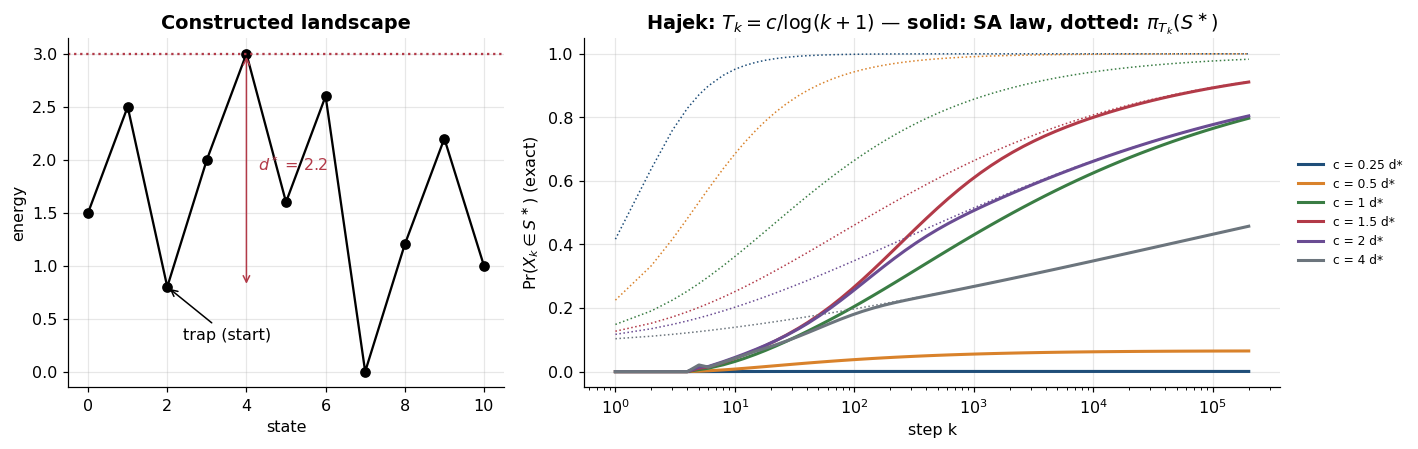

at k = K: SA law P(S*)         [0.001 0.065 0.797 0.911 0.805 0.457]
          equilibrium pi_T(S*) [1.    1.    0.983 0.912 0.805 0.457]


In [3]:
def boltz(E, T):
    w = np.exp(-(E - E.min()) / T); return w / w.sum()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1, 1.6]})
ax[0].plot(E_line, "o-", c="k")
ax[0].annotate("trap (start)", (trap, E_line[trap]), (trap + 0.4, E_line[trap] - 0.5), arrowprops=dict(arrowstyle="->"))
ax[0].annotate("", (trap + 2, E_line[trap] + d_star), (trap + 2, E_line[trap]), arrowprops=dict(arrowstyle="<->", color=PALETTE["red"]))
ax[0].text(trap + 2.3, E_line[trap] + d_star / 2, f"$d^*$ = {d_star:.1f}", color=PALETTE["red"])
ax[0].axhline(E_line[trap] + d_star, ls=":", c=PALETTE["red"])
ax[0].set_xlabel("state"); ax[0].set_ylabel("energy"); ax[0].set_title("Constructed landscape")
for j, r in enumerate(ratios):
    line, = ax[1].semilogx(ks_sorted, P_glob[:, j], lw=2, label=f"c = {r:g} d*")
    ax[1].semilogx(ks_sorted, [boltz(E_line, r * d_star / np.log(k + 1))[glob] for k in ks_sorted],
                   ls=":", c=line.get_color(), lw=1)
ax[1].set_xlabel("step k"); ax[1].set_ylabel(r"$\Pr(X_k \in S^\ast)$ (exact)")
ax[1].set_title(r"Hajek: $T_k=c/\log(k+1)$ — solid: SA law, dotted: $\pi_{T_k}(S^\ast)$")
ax[1].legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout(); savefig("w2_hajek_threshold.png"); plt.show()
eq_end = np.array([boltz(E_line, r * d_star / np.log(K_line + 1))[glob] for r in ratios])
print("at k = K: SA law P(S*)        ", np.round(P_glob[-1], 3))
print("          equilibrium pi_T(S*)", np.round(eq_end, 3))

**Reading the figure.** For $c \lt d^{\ast}$ the curves freeze well below 1: the chain never climbs out of the trap
— exactly the Borel–Cantelli failure. For $c \ge d^{\ast}$ the mass on $S^{\ast}$ keeps growing, but only
*logarithmically* in $k$; and the dotted equilibrium curves show the second face of the trade-off: a large $c$
escapes quickly but, at any finite $k$, $T_k$ is still hot and $\pi_{T_k}(S^{\ast})$ is low ($c = 4d^{\ast}$ is
worse than $c = 1.5d^{\ast}$ at the end). Comparing solid with dotted curves separates the two failure modes: at
$c = d^{\ast}$ the chain still lags far behind quasi-equilibrium at $k = 2\times10^5$ (the SA law puts $0.80$ on
$S^{\ast}$ while $\pi_{T_k}(S^{\ast})\approx 0.98$, printed below) — it is limited by barrier crossing; for
$c\ge 1.5d^{\ast}$ the lag, visible at intermediate $k$, has closed by the end and the chain is limited by the
temperature itself. This is why nobody uses the logarithmic schedule in practice: it is the price of a guarantee
*for every landscape*, while the budget is always finite.

## 3. A benchmark with $2^{n}$ states: the Sherrington–Kirkpatrick spin glass

The SK model (Sherrington & Kirkpatrick 1975) has spins $s\in\lbrace -1,+1\rbrace^n$ and energy
$E(s) = -\sum_{i\lt j} J_{ij}s_is_j$ with i.i.d. $J_{ij}\sim\mathcal N(0, 1/n)$. Finding its ground state is NP-hard
in general (Barahona 1982 for spin glasses; SK is an instance of MAX-CUT/QUBO), it is the textbook "rugged"
landscape, and Parisi's solution gives the ground-state energy per spin in the limit, $e_\infty\approx -0.7633$
(Parisi 1979/1980; proved by Talagrand 2006). It is also a QUBO — the same form as many binary ML problems
(feature selection with pairwise redundancy, binary neural-network weights).

**Single-flip neighbourhood with $O(1)$ delta.** Keep local fields $h_i = \sum_j J_{ij}s_j$. Flipping $s_i$ changes the
energy by $\Delta_i = 2s_ih_i$ (read in $O(1)$); after an accepted flip, $h \leftarrow h - 2s_i^{\text{old}}J_{:,i}$
($O(n)$). We run $R$ independent chains **in parallel** as NumPy arrays and count one evaluation per proposed flip.

Every acceptance rule below is a function `rule(k, E_cur, E_new, E_best, u) -> accept mask`, with its own state;
the engine is shared, so differences come *only* from the acceptance mechanism.

In [4]:
def sk_instance(n, rng):
    G = rng.standard_normal((n, n))
    J = np.triu(G, 1); J = (J + J.T) / np.sqrt(n)
    return J


def sk_energy(S, J):
    S = np.atleast_2d(S)
    return -0.5 * np.einsum("ri,ij,rj->r", S, J, S)


def run_chains(J, S0, n_steps, rule, rng, n_trace=100):
    """Run R single-flip chains in parallel; returns final states, best energies and a best-so-far trace."""
    S = S0.astype(float).copy()
    R, n = S.shape
    Hf = S @ J
    E_cur = -0.5 * np.sum(S * Hf, axis=1)
    E_best = E_cur.copy()
    rows = np.arange(R)
    trace_at = set(np.linspace(0, n_steps, n_trace + 1).astype(int)[1:])
    trace = []
    block = 4096
    for k0 in range(0, n_steps, block):
        m = min(block, n_steps - k0)
        I = rng.integers(0, n, (m, R)); U = rng.random((m, R))
        for t in range(m):
            k = k0 + t
            i = I[t]
            s_i = S[rows, i]
            dE = 2.0 * s_i * Hf[rows, i]
            E_new = E_cur + dE
            acc = rule(k, E_cur, E_new, E_best, U[t])
            idx = np.flatnonzero(acc)
            if idx.size:
                Hf[idx] -= 2.0 * s_i[idx, None] * J[i[idx]]
                S[idx, i[idx]] = -s_i[idx]
                E_cur[idx] = E_new[idx]
                np.minimum(E_best, E_cur, out=E_best)
            if k + 1 in trace_at:
                trace.append(E_best.copy())
    return S, E_best, E_cur, np.array(trace)


# --- validation 1: exact ground state by enumeration for n = 16, and incremental energy bookkeeping
n_small = 16
J16 = sk_instance(n_small, np.random.default_rng(11))
all_S = np.array(list(product([-1.0, 1.0], repeat=n_small)))
E_all = sk_energy(all_S, J16)
E16_opt = E_all.min()
metro = lambda T: (lambda k, Ec, En, Eb, u: (En <= Ec) | (u < np.exp(-np.maximum(En - Ec, 0) / T(k))))
S_end, Eb16, Ec16, _ = run_chains(J16, np.random.default_rng(1).choice([-1.0, 1.0], (20, n_small)), 20_000,
                                  metro(lambda k: 1.0 * 0.9997**k), np.random.default_rng(2))
check_close(np.max(np.abs(Ec16 - sk_energy(S_end, J16))), 0.0,
            "incremental energies vs full recomputation, max abs difference over 20 chains", atol=1e-9)
check_close(Eb16.min(), E16_opt, f"SA reaches the exact ground state of an n={n_small} SK instance (2^16 enumeration)", atol=1e-9)
print(f"fraction of the 20 chains reaching the exact ground state: {np.mean(np.abs(Eb16 - E16_opt) < 1e-9):.0%}")

[PASS] incremental energies vs full recomputation, max abs difference over 20 chains: got 0.0, expected 0.0
[PASS] SA reaches the exact ground state of an n=16 SK instance (2^16 enumeration): got -8.47791, expected -8.47791
fraction of the 20 chains reaching the exact ground state: 100%


## 4. Initial temperature from a target acceptance ratio

A good $T_0$ makes a prescribed fraction $\chi_0$ of *uphill* moves acceptable at the start — the idea goes back to
Kirkpatrick et al. (1983), and $\chi_0\approx 0.8$ is the value usually quoted in the textbooks (van Laarhoven & Aarts
1987). Sample uphill deltas $\Delta^+_1,\dots,\Delta^+_M$ from random states. Two estimators:

* the classical closed form, $T_0^{\text{K}} = -\overline{\Delta^+}/\ln\chi_0$ (solves $e^{-\overline{\Delta^+}/T}=\chi_0$);
* the exact empirical one, the root of $\frac1M\sum_m e^{-\Delta_m^+/T} = \chi_0$ (monotone in $T$; Ben-Ameur 2004
  solves a closely related equation, built from sampled pairs of energies, by a fixed-point iteration).

By **Jensen's inequality** ($e^{-x/T}$ is convex), $\frac1M\sum e^{-\Delta^+_m/T^{\text{K}}_0} \ge e^{-\overline{\Delta^+}/T^{\text{K}}_0} = \chi_0$,
so the classical estimate is always *too hot*: $T_0^{\text{exact}} \le T_0^{\text{K}}$. We verify both claims and
check on fresh samples that $T_0^{\text{exact}}$ really yields acceptance $\chi_0$. The tolerance is statistical: the
fresh acceptance differs from $\chi_0$ because $T_0^{\text{exact}}$ was fitted on a finite sample (standard error
$\approx s/\sqrt{M}$, $s$ = standard deviation of $e^{-\Delta^+/T_0}$) and because the fresh sample is finite
($s/\sqrt{M_{\text{fresh}}}$); we allow 4 combined standard errors.

In [5]:
n_sk = 100
J = sk_instance(n_sk, np.random.default_rng(42))


def sample_uphill(J, M, rng):
    n = len(J)
    S = rng.choice([-1.0, 1.0], (M, n))
    i = rng.integers(0, n, M)
    d = 2 * S[np.arange(M), i] * (S @ J)[np.arange(M), i]
    return d[d > 0]


chi0 = 0.8
d_up = sample_uphill(J, 4000, np.random.default_rng(3))
T0_K = -d_up.mean() / np.log(chi0)
T0 = brentq(lambda T: np.mean(np.exp(-d_up / T)) - chi0, 1e-6, 1e6)
fresh = sample_uphill(J, 40000, np.random.default_rng(4))
acc_fresh = np.mean(np.exp(-fresh / T0))
print(f"{d_up.size} uphill samples: T0 (classical) = {T0_K:.3f}, T0 (exact root) = {T0:.3f}")
check_true(T0 <= T0_K, "Jensen: exact T0 <= classical T0 (classical estimate is too hot)")
s_acc = np.exp(-fresh / T0).std()
se_acc = s_acc * np.sqrt(1 / d_up.size + 1 / fresh.size)
check_close(acc_fresh, chi0, f"uphill acceptance at T0 on {fresh.size} fresh samples (4 s.e. = {4 * se_acc:.4f})", atol=4 * se_acc, rtol=0)
print(f"acceptance of uphill moves at the classical T0: {np.mean(np.exp(-fresh / T0_K)):.3f} (target {chi0})")

1902 uphill samples: T0 (classical) = 7.180, T0 (exact root) = 6.717
[PASS] Jensen: exact T0 <= classical T0 (classical estimate is too hot)
[PASS] uphill acceptance at T0 on 19743 fresh samples (4 s.e. = 0.0127): got 0.800667, expected 0.8
acceptance of uphill moves at the classical T0: 0.812 (target 0.8)


## 5. The schedules and the alternative acceptance rules

All rules below use the *same* proposal (random single flip) and the *same* budget of $K$ proposals per chain.
With $t = k/K\in[0,1]$:

| Rule | Accept $y$ if | Control parameter |
|---|---|---|
| SA, **geometric** (Kirkpatrick et al. 1983) | $u \lt e^{-\Delta/T_k}$, $T_k = T_0\alpha^k$ | $\alpha$ s.t. $T_K = T_{\text{end}}$ |
| SA, **linear** | same, $T_k = T_0(1-t)+T_{\text{end}}\,t$ | — |
| SA, **logarithmic** (Geman & Geman 1984; Hajek 1988) | same, $T_k = T_0\ln 2/\ln(k+2)$ | $c = T_0\ln2$ |
| SA, **adaptive** (Lam & Delosme 1988, "modified Lam") | same; $T\leftarrow 0.999T$ if the running acceptance rate exceeds a target profile $\rho(t)$, else $T\leftarrow T/0.999$ | $\rho(t)$ |
| SA, **geometric + reheating** | same; fast geometric cooling, and whenever $T\lt T_{\text{end}}$ reheat to $T_0/5$ | cycles |
| **Threshold accepting** (Dueck & Scheuer 1990) | $\Delta \lt \tau_k$, $\tau_k = \tau_0(1-t)$ | $\tau_0$ |
| **Great deluge** (Dueck 1993) | $E(y) \le B_k$ (a "water level"), $B_k$ lowered linearly from $E(x_0)$ to a target; improving moves are also accepted (the variant of Burke et al. 2004) | target level |
| **Record-to-record travel** (Dueck 1993) | $E(y) \lt E_{\text{best}} + D$ | deviation $D$ |
| **Late acceptance HC** (Burke & Bykov 2008/2017) | $E(y)\le E(x)$ or $E(y) \le \hat E_{k \bmod L}$ (current energy $L$ steps ago) | history length $L$ |
| Hill climbing (baseline) | $\Delta \le 0$ | — |

The modified-Lam target profile (Lam & Delosme 1988; Swartz & Sechen 1990; Boyan 1998) is
$\rho(t) = 0.44 + 0.56\cdot 560^{-t/0.15}$ for $t\lt0.15$, $\rho=0.44$ for $0.15\le t\lt0.65$, and
$0.44\cdot440^{-(t-0.65)/0.35}$ afterwards — a long plateau at the acceptance rate 0.44 that Lam & Delosme derived
as optimal for their statistical cooling criterion.

The deterministic rules (TA, GD, RRT, LAHC) need no random numbers for acceptance and no exponentials; they are
*not* Markov chains with a Boltzmann stationary law (GD, RRT and LAHC even depend on the path), so none of the theory
of Section 1 applies to them — they are judged only empirically.

In [6]:
def make_rule(name, K, T0, T_end, **p):
    """Return a fresh acceptance rule (closure with its own state) and a temperature log (chain 0)."""
    log = []
    if name in ("SA geometric", "SA linear", "SA logarithmic"):
        if name == "SA geometric":
            a = (T_end / T0) ** (1 / K); T = lambda k: T0 * a**k
        elif name == "SA linear":
            T = lambda k: T0 * (1 - k / K) + T_end * k / K
        else:
            T = lambda k: T0 * np.log(2) / np.log(k + 2)
        def rule(k, Ec, En, Eb, u):
            Tk = T(k); log.append(Tk)
            return (En <= Ec) | (u < np.exp(-np.maximum(En - Ec, 0) / Tk))
    elif name == "SA adaptive (mod. Lam)":
        st = {"T": None, "acc": None}
        def target(t):
            if t < 0.15:
                return 0.44 + 0.56 * 560 ** (-t / 0.15)
            if t < 0.65:
                return 0.44
            return 0.44 * 440 ** (-(t - 0.65) / 0.35)
        def rule(k, Ec, En, Eb, u):
            if st["T"] is None:
                st["T"] = np.full(Ec.shape, T0); st["acc"] = np.full(Ec.shape, 0.5)
            acc = (En <= Ec) | (u < np.exp(-np.maximum(En - Ec, 0) / st["T"]))
            st["acc"] = (499 * st["acc"] + acc) / 500
            st["T"] = np.where(st["acc"] > target(k / K), st["T"] * 0.999, st["T"] / 0.999)
            log.append(st["T"][0])
            return acc
    elif name == "SA geo + reheating":
        n_cycles = p.get("cycles", 4)
        a = (T_end / T0) ** (n_cycles / K)
        st = {"T": None}
        def rule(k, Ec, En, Eb, u):
            if st["T"] is None:
                st["T"] = np.full(Ec.shape, T0)
            T = st["T"]
            acc = (En <= Ec) | (u < np.exp(-np.maximum(En - Ec, 0) / T))
            T *= a
            T[T < T_end] = T0 / 5
            log.append(T[0])
            return acc
    elif name == "Threshold accepting":
        tau0 = p["tau0"]
        def rule(k, Ec, En, Eb, u):
            tau = tau0 * (1 - k / K); log.append(tau)
            return (En - Ec) < tau + 1e-12
    elif name == "Great deluge":
        st = {"B0": None}
        def rule(k, Ec, En, Eb, u):
            if st["B0"] is None:
                st["B0"] = Ec.copy()
            B = st["B0"] + (p["target"] - st["B0"]) * (k / K)
            log.append(B[0])
            return (En <= B) | (En <= Ec)
    elif name == "Record-to-record":
        def rule(k, Ec, En, Eb, u):
            return (En < Eb + p["D"]) | (En <= Ec)
    elif name == "Late acceptance HC":
        L = p["L"]; st = {"hist": None}
        def rule(k, Ec, En, Eb, u):
            if st["hist"] is None:
                st["hist"] = np.tile(Ec, (L, 1))
            v = k % L
            acc = (En <= Ec) | (En <= st["hist"][v])
            st["hist"][v] = np.where(acc, En, Ec)
            return acc
    elif name == "Hill climbing":
        def rule(k, Ec, En, Eb, u):
            return En <= Ec
    else:
        raise ValueError(name)
    return rule, log

**Protocol.** Budget $K = 300$ sweeps $= 3\times10^4$ proposals per run, $n = 100$ spins, $T_0$ from $\chi_0 = 0.8$
(Section 4), $T_{\text{end}} = T_0/200$ for the geometric-type schedules. The single parameter of each
deterministic rule (TA's $\tau_0$, GD's target level, RRT's $D$, LAHC's $L$) and SA's $T_{\text{end}}$ are tuned on a
**separate pilot instance** (different seed) over a small grid with 8 chains, then frozen — tuning on the test
instance would flatter those rules. The test uses 24 runs per rule from **common random initial states** (run $r$ of
every rule starts from the same $s_0^{(r)}$), which allows paired Wilcoxon signed-rank tests.

In [7]:
K = 300 * n_sk
pilot_J = sk_instance(n_sk, np.random.default_rng(7))
pilot_S0 = np.random.default_rng(8).choice([-1.0, 1.0], (8, n_sk))
T0_pilot = brentq(lambda T: np.mean(np.exp(-sample_uphill(pilot_J, 4000, np.random.default_rng(9)) / T)) - chi0, 1e-6, 1e6)
grids = {
    "SA geometric": ("T_end", [T0_pilot / 200, T0_pilot / 2000, T0_pilot / 20000]),
    "Threshold accepting": ("tau0", [0.25 * T0_pilot, 0.5 * T0_pilot, T0_pilot]),
    "Great deluge": ("target", [-0.70 * n_sk, -0.74 * n_sk, -0.78 * n_sk]),
    "Record-to-record": ("D", [0.3, 1.0, 3.0]),
    "Late acceptance HC": ("L", [30, 100, 300, 1000]),
}
tuned = {}
for name, (key, values) in grids.items():
    scores = []
    for v in values:
        kw = {key: v}
        T_end = kw.pop("T_end", T0_pilot / 200)
        rule, _ = make_rule(name, K, T0_pilot, T_end, **kw)
        _, Eb, _, _ = run_chains(pilot_J, pilot_S0, K, rule, np.random.default_rng(10))
        scores.append(np.median(Eb))
    tuned[name] = (key, values[int(np.argmin(scores))])
    print(f"pilot {name:20s} {key}: " + ", ".join(f"{v:.3g}->{s / n_sk:.4f}" for v, s in zip(values, scores)))
# express the tuned values relative to T0 so they transfer to the test instance
T_end_ratio = tuned["SA geometric"][1] / T0_pilot
tau_ratio = tuned["Threshold accepting"][1] / T0_pilot
print(f"tuned: T_end = T0/{1 / T_end_ratio:.0f}, tau0 = {tau_ratio:.2f} T0, GD target = {tuned['Great deluge'][1] / n_sk:.2f} n, "
      f"RRT D = {tuned['Record-to-record'][1]}, LAHC L = {tuned['Late acceptance HC'][1]}")

pilot SA geometric         T_end: 0.0331->-0.7238, 0.00331->-0.7240, 0.000331->-0.7181


pilot Threshold accepting  tau0: 1.65->-0.7240, 3.31->-0.7267, 6.62->-0.7175


pilot Great deluge         target: -70->-0.7051, -74->-0.7235, -78->-0.7074


pilot Record-to-record     D: 0.3->-0.6928, 1->-0.7237, 3->-0.7103


pilot Late acceptance HC   L: 30->-0.7123, 100->-0.7127, 300->-0.7125, 1e+03->-0.5047
tuned: T_end = T0/2000, tau0 = 0.50 T0, GD target = -0.74 n, RRT D = 1.0, LAHC L = 100


In [8]:
def holm(pvals):
    """Holm (1979) step-down adjustment of a dict of p-values (controls the family-wise error rate)."""
    names = sorted(pvals, key=pvals.get)
    m, out, running = len(names), {}, 0.0
    for i, nm in enumerate(names):
        running = max(running, min(1.0, (m - i) * pvals[nm]))
        out[nm] = running
    return out


R = 24
S0 = np.random.default_rng(123).choice([-1.0, 1.0], (R, n_sk))
T_end = T0 * T_end_ratio
configs = {
    "SA geometric": {}, "SA linear": {}, "SA logarithmic": {}, "SA adaptive (mod. Lam)": {}, "SA geo + reheating": {},
    "Threshold accepting": {"tau0": tau_ratio * T0}, "Great deluge": {"target": tuned["Great deluge"][1]},
    "Record-to-record": {"D": tuned["Record-to-record"][1]}, "Late acceptance HC": {"L": tuned["Late acceptance HC"][1]},
    "Hill climbing": {},
}
results, traces, temp_logs = {}, {}, {}
for name, kw in configs.items():
    rule, log = make_rule(name, K, T0, T_end, **kw)
    _, Eb, _, tr = run_chains(J, S0, K, rule, np.random.default_rng(999))
    results[name], traces[name], temp_logs[name] = Eb, tr, np.array(log)
E_ref = min(v.min() for v in results.values())
print(f"best energy found by any run: E/n = {E_ref / n_sk:.4f}   (Parisi limit e_inf = -0.7633)")
base = results["SA geometric"]
raw_p = {name: wilcoxon(Eb, base).pvalue for name, Eb in results.items() if name != "SA geometric"}
holm_p = holm(raw_p)
print(f"{'rule':24s} {'median gap %':>12s} {'IQR':>16s} {'hit best':>9s} {'Wilcoxon p vs SA-geo':>21s} {'Holm-adjusted':>14s}")
for name, Eb in results.items():
    gap = 100 * (Eb - E_ref) / abs(E_ref)
    q1, med, q3 = np.percentile(gap, [25, 50, 75])
    pval = "—" if name == "SA geometric" else f"{raw_p[name]:.2g}"
    padj = "—" if name == "SA geometric" else f"{holm_p[name]:.2g}"
    print(f"{name:24s} {med:12.2f} [{q1:6.2f}, {q3:6.2f}] {np.mean(Eb - E_ref < 1e-9):9.0%} {pval:>21s} {padj:>14s}")
print("\nfraction of the budget spent at 0.3 <= T <= 1 (SK spin-glass transition: T_c = 1):")
for name in ["SA geometric", "SA linear", "SA logarithmic", "SA adaptive (mod. Lam)", "SA geo + reheating"]:
    Tl = temp_logs[name]
    print(f"  {name:24s} {np.mean((Tl >= 0.3) & (Tl <= 1.0)):.0%}   (final T = {Tl[-1]:.3g})")

best energy found by any run: E/n = -0.7240   (Parisi limit e_inf = -0.7633)
rule                     median gap %              IQR  hit best  Wilcoxon p vs SA-geo  Holm-adjusted
SA geometric                     1.11 [  0.00,   2.69]       33%                     —              —
SA linear                        2.58 [  1.24,   3.34]        4%                  0.11           0.57
SA logarithmic                   0.03 [  0.00,   0.30]       46%                0.0031          0.025
SA adaptive (mod. Lam)           1.45 [  0.03,   4.47]       12%                 0.095           0.57
SA geo + reheating               0.58 [  0.02,   2.26]       25%                  0.28           0.83
Threshold accepting              1.20 [  0.02,   2.79]       25%                  0.99           0.99
Great deluge                     3.74 [  0.59,   6.02]        4%                 0.012          0.081
Record-to-record                 2.56 [  0.02,   4.05]       25%                  0.21           0.83
Late 

**Validation of the statistics code.** `scipy.stats.wilcoxon` is used as a reference; we check our reading of it
with an exact permutation computation on a small paired sample (all $2^{10}$ sign flips), which is precisely the
null distribution of the signed-rank statistic without ties. We use a pair with a *non-extreme* $p$-value (geometric
SA vs threshold accepting, first 10 runs) so that the whole null distribution, not only its tail, is exercised; the
Holm adjustment is checked against a direct implementation of its definition.

In [9]:
a_, b_ = results["SA geometric"][:10], results["Threshold accepting"][:10]
d_ = a_ - b_
assert np.all(d_ != 0) and len(np.unique(np.abs(d_))) == 10, "exact enumeration below assumes no zeros and no ties"
ranks = np.argsort(np.argsort(np.abs(d_))) + 1
W_obs = min(ranks[d_ > 0].sum(), ranks[d_ < 0].sum())
signs = np.array(list(product([0, 1], repeat=10)))
W_pos = signs @ ranks
W_null = np.minimum(W_pos, ranks.sum() - W_pos)
p_exact = np.mean(W_null <= W_obs)
check_close(wilcoxon(a_, b_).pvalue, p_exact, "scipy Wilcoxon p-value = exact enumeration of 2^10 sign patterns", atol=1e-12)
# Holm by definition: reject H_(i) iff p_(j) <= alpha/(m-j+1) for all j <= i; adjusted p = smallest alpha that rejects
alphas = np.linspace(0, 1, 100001)
ps = np.array(sorted(raw_p.values())); m_ = len(ps)
rej = np.cumprod(ps[None, :] <= alphas[:, None] / (m_ - np.arange(m_))[None, :], axis=1).astype(bool)
holm_def = np.array([alphas[np.argmax(rej[:, i])] if rej[:, i].any() else 1.0 for i in range(m_)])
check_close(np.array(sorted(holm_p.values())), holm_def, "Holm adjustment = its step-down definition (grid 1e-5)", atol=2e-5, rtol=0)

[PASS] scipy Wilcoxon p-value = exact enumeration of 2^10 sign patterns: got 0.193359, expected 0.193359
[PASS] Holm adjustment = its step-down definition (grid 1e-5): got [8.00000e-06 2.51450e-02 8.06130e-02 5.70576e-01 5.70576e-01 8.30466e-01
 8.30466e-01 8.30466e-01 9.88813e-01], expected [1.0000e-05 2.5150e-02 8.0620e-02 5.7058e-01 5.7058e-01 8.3047e-01
 8.3047e-01 8.3047e-01 9.8882e-01]


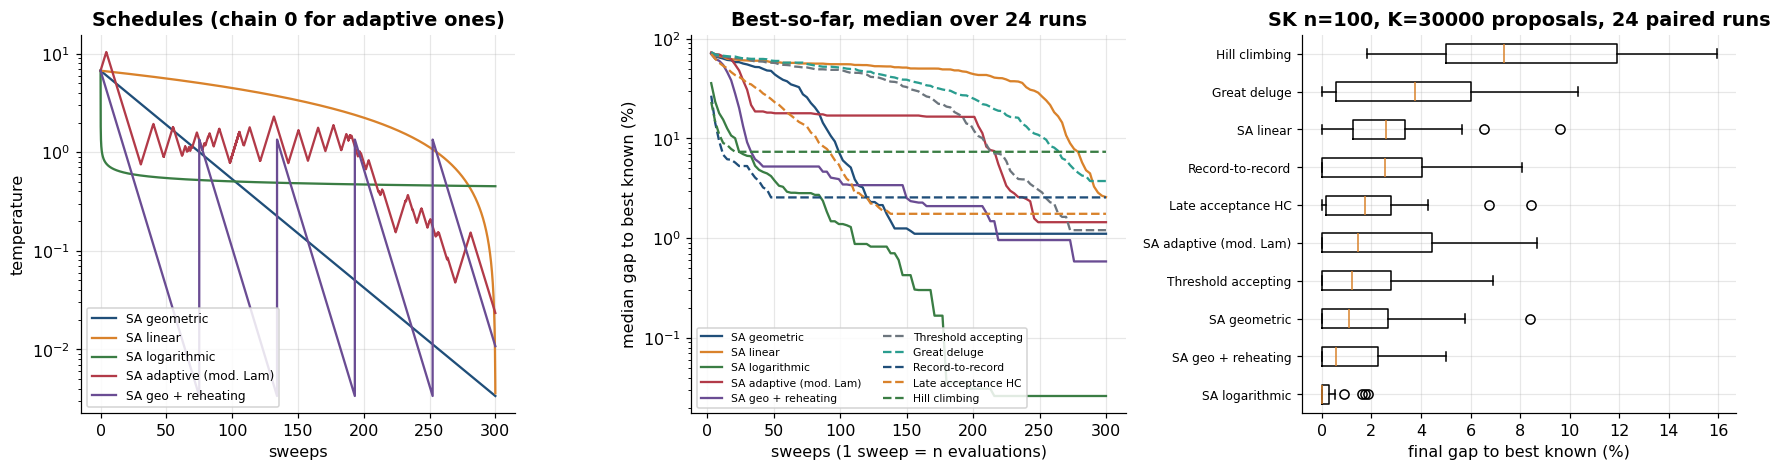

In [10]:
grid = np.linspace(0, K, traces["SA geometric"].shape[0] + 1)[1:]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
for name in ["SA geometric", "SA linear", "SA logarithmic", "SA adaptive (mod. Lam)", "SA geo + reheating"]:
    ax[0].semilogy(np.arange(len(temp_logs[name])) / n_sk, temp_logs[name], label=name)
ax[0].set_xlabel("sweeps"); ax[0].set_ylabel("temperature"); ax[0].set_title("Schedules (chain 0 for adaptive ones)")
ax[0].legend(fontsize=8, frameon=True, framealpha=0.85)
for name in configs:
    tr = 100 * (traces[name] - E_ref) / abs(E_ref)
    med = np.median(tr, axis=1)
    ls = "-" if name.startswith("SA") else "--"
    ax[1].semilogy(grid / n_sk, np.maximum(med, 1e-2), ls, label=name)
ax[1].set_xlabel("sweeps (1 sweep = n evaluations)"); ax[1].set_ylabel("median gap to best known (%)")
ax[1].set_title("Best-so-far, median over 24 runs"); ax[1].legend(fontsize=7, ncol=2, frameon=True, framealpha=0.85)
names = list(configs)
order = np.argsort([np.median(results[m]) for m in names])
ax[2].boxplot([100 * (results[names[i]] - E_ref) / abs(E_ref) for i in order], vert=False)
ax[2].set_yticks(range(1, len(names) + 1), [names[i] for i in order], fontsize=8)
ax[2].set_xlabel("final gap to best known (%)"); ax[2].set_title(f"SK n={n_sk}, K={K} proposals, 24 paired runs")
plt.tight_layout(); savefig("w2_schedule_comparison.png"); plt.show()

**Reading the results.** (All numbers above; one instance and 24 paired runs, so treat the ranking as indicative —
Exercise 5 asks for several instances.)

* **Multiple testing.** Nine rules are compared with geometric SA, so the raw $p$-values are also reported after
  Holm's step-down correction (family-wise error rate 5%). Only two differences survive: hill climbing and the
  logarithmic schedule.
* **Hill climbing** stops in the first local minimum within a few sweeps; its median gap (7.4%) is about twice
  that of the worst other rule (great deluge, 3.7%), and against geometric SA the difference is overwhelming (Wilcoxon $p\approx10^{-6}$).
* **A surprise: the logarithmic schedule wins** (median gap 0.03% vs 1.11% for geometric, $p = 0.003$, Holm-adjusted
  $p = 0.025$). Not because
  of Hajek's guarantee — its final temperature $T_K = T_0\ln 2/\ln(K+1)\approx 0.45$ is far from frozen, so the
  final *state* is poor and only the best-so-far is good — but because it spends essentially the **whole budget in
  the window $0.3\le T\le 1$**, just below the SK spin-glass transition $T_c = 1$, where the energy actually goes
  down. The geometric, linear, adaptive and reheating schedules, started at the $\chi_0 = 0.8$ temperature
  $T_0\approx 6.7$ and ending near $10^{-2}$–$10^{-3}$, spend only 10–20% of the budget there (printed above).
  The lesson is about *where the budget goes*, not about the functional form of $T_k$: with $3\times 10^4$
  proposals, a hot start and a very cold end are both wasted.
* Among the tuned alternatives, **threshold accepting, record-to-record travel and late acceptance** are
  statistically indistinguishable from geometric SA here ($p \ge 0.2$), in line with Dueck's and Burke–Bykov's
  reports that these rules are competitive with SA; **great deluge** is worse in median and nominally significant
  ($p\approx 0.01$), but this does not survive the Holm correction — at most a hint that a level decreasing on a
  fixed timetable, whatever the search is doing, with a guessed target, is a handicap.
* The pilot grids show how sensitive the deterministic rules are to their single parameter (e.g. LAHC with
  $L=1000$ loses 30% of the energy, because a long history makes it accept almost everything for most of a short
  budget): "parameter-light" is not "parameter-free".
* The Parisi value $-0.7633$ is the $n\to\infty$ limit; finite-$n$ ground states lie above it on average
  (finite-size corrections of order $n^{-2/3}$; Boettcher 2005) and fluctuate between instances, so the best value
  found ($E/n = -0.724$) is plausible, but with this budget we cannot certify that it is the ground state — the gaps
  are measured to the best known, not to the optimum.

**AI relevance.** Late acceptance and threshold rules are popular in scheduling and timetabling solvers because
they have one intuitive parameter; acceptance-rate targeting (adaptive schedules) is the same idea as step-size
adaptation in MCMC and learning-rate warm-up/decay heuristics — a schedule tuned to what the process is *doing*
rather than to the clock.

## Key takeaways

- SA is an inhomogeneous Markov chain; **Hajek's theorem** pins the logarithmic schedule exactly: $c\ge d^{\ast}$ is
  necessary and sufficient. We reproduced the threshold exactly (freezing for $c\lt d^{\ast}$, slow logarithmic
  growth for $c\ge d^{\ast}$) and saw why it is useless at finite budgets.
- Initial temperature should be computed from sampled uphill moves; the classical $-\overline{\Delta^+}/\ln\chi_0$ is
  provably too hot (Jensen), the root of the empirical acceptance equation is exact.
- What decides SA's quality at a finite budget is **how much of the budget is spent in the temperature window where
  the energy decreases** (here just below the spin-glass transition $T_c=1$); the logarithmic schedule won on
  SK only because it lives in that window, and a hot $T_0$ from $\chi_0 = 0.8$ wastes most of a short budget.
- Threshold accepting, record-to-record travel and late acceptance replace the Metropolis coin flip by deterministic
  thresholds; tuned on a pilot instance they were statistically indistinguishable from geometric SA at equal budget
  (great deluge was worse in median, not significantly after a Holm correction) — and all of them are sensitive to
  their single parameter.
- With many pairwise tests, report multiplicity-adjusted $p$-values (Holm) alongside the raw ones.
- Statistical honesty: common random initial states, paired tests, parameters tuned on separate instances.

## Exercises

1. ★ Show that on a finite space with $T_k = c/\log(k+1)$ a given uphill move of height $h$ is accepted with
   probability $(k+1)^{-h/c}$ at step $k$, and use $\sum_k (k+1)^{-p}\lt\infty \iff p\gt 1$ to explain (heuristically,
   via Borel–Cantelli) why the expected number of escapes from the deepest trap is infinite iff $c\ge d^{\ast}$.
2. ★ Prove that the empirical acceptance equation $\frac1M\sum_m e^{-\Delta_m^+/T}=\chi_0$ has a unique root for
   $\chi_0\in(0,1)$, and that $T_0^{\text{exact}}\to T_0^{\text{K}}$ when all $\Delta^+_m$ are equal.
3. ★★ Modify the constructed landscape so that two non-global minima have depths $1$ and $2$ and rerun the exact
   propagation. Verify numerically that the threshold is governed by the *deeper* one, and plot the time to reach
   $\Pr(S^{\ast})\ge 0.5$ against $c$.
4. ★★ Implement Aarts & van Laarhoven's (1985) adaptive decrement $T_{j+1}=T_j/(1+T_j\ln(1+\delta)/(3\sigma_j))$,
   where $\sigma_j$ is the energy standard deviation observed at $T_j$ (homogeneous stages of fixed length), and
   add it to the comparison.
5. ★★ Repeat the SK comparison on 10 test instances (tuning still on separate pilots). Rank the rules on each
   instance and apply a Friedman test (`scipy.stats.friedmanchisquare`); which differences survive?
6. ★★★ (a) Prove that record-to-record travel with deviation $D \lt d^{\ast}$, started at the deepest trap (which is then
   its first record), never reaches $S^{\ast}$. (b) Prove that great deluge started at $x_0$ can never visit a state
   with energy above $E(x_0)$ for any target level $\le E(x_0)$, and conclude which traps it can escape. (c) Implement both
   rules on the line landscape of Section 2 and confirm (a) and (b) by simulation; then find by experiment the
   smallest $D$ for which RRT reaches $S^{\ast}$ from the trap within $10^4$ steps in at least 90% of runs.